# Comparitive Analysis
---

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict

# --- Config ---
RESULTS_DIR = '../results/base/'
N_NODES     = 1000
PROTOCOLS   = ['kadcast', 'kadrlnc', 'optimump2p']
COLORS      = {'kadcast': '#E63946', 'kadrlnc': '#2A9D8F', 'optimump2p': '#E9C46A'}
LABELS      = {'kadcast': 'Kadcast', 'kadrlnc': 'KadRLNC', 'optimump2p': 'OPTIMUMP2P'}

plt.rcParams.update({
    'figure.dpi'      : 150,
    'font.family'     : 'monospace',
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.3,
    'grid.linestyle'  : '--',
})
print('Setup complete.')

Setup complete.


In [2]:
# =============================================================================
# Load all CSVs
# =============================================================================

def load_protocol_data(results_dir, protocols):
    deliveries = {}
    messages   = {}

    for protocol in protocols:
        d_frames, m_frames = [], []

        d_files = sorted(glob.glob(os.path.join(results_dir, f'{protocol}_*_deliveries.csv')))
        m_files = sorted(glob.glob(os.path.join(results_dir, f'{protocol}_*_messages.csv')))

        for path in d_files:
            seed = int(os.path.basename(path).split('_')[1])
            df   = pd.read_csv(path)
            df['seed'] = seed
            d_frames.append(df)

        for path in m_files:
            seed = int(os.path.basename(path).split('_')[1])
            df   = pd.read_csv(path)
            df['seed'] = seed
            m_frames.append(df)

        deliveries[protocol] = pd.concat(d_frames, ignore_index=True) if d_frames else pd.DataFrame()
        messages[protocol]   = pd.concat(m_frames, ignore_index=True) if m_frames else pd.DataFrame()

        seeds_found = deliveries[protocol]['seed'].nunique() if not deliveries[protocol].empty else 0
        print(f'{protocol}: {seeds_found} seeds loaded')

    return deliveries, messages


deliveries, messages = load_protocol_data(RESULTS_DIR, PROTOCOLS)

kadcast: 10 seeds loaded
kadrlnc: 10 seeds loaded
optimump2p: 10 seeds loaded


In [3]:
# =============================================================================
# Compute relative delivery times per (seed, block)
# =============================================================================

def make_relative(df):
    """
    Subtract the min time_ms per (seed, block_id) group so all blocks
    start at t=0 (source decode time).
    """
    df = df.copy()
    df['rel_time'] = df['time_ms'] - df.groupby(['seed', 'block_id'])['time_ms'].transform('min')
    return df

for p in PROTOCOLS:
    deliveries[p] = make_relative(deliveries[p])

print('Relative times computed.')

Relative times computed.


In [4]:
# =============================================================================
# 1. Coverage table — did each protocol always reach all nodes?
# =============================================================================

print(f"{'Protocol':<14} {'Seeds':>6} {'Blocks':>7} {'Min nodes':>10} {'Max nodes':>10} {'Mean nodes':>11}")
print('-' * 55)
for p in PROTOCOLS:
    df      = deliveries[p]
    per_run = df.groupby(['seed', 'block_id'])['node_id'].count()
    print(f"{LABELS[p]:<14} {df['seed'].nunique():>6} {df['block_id'].nunique():>7} "
          f"{per_run.min():>10} {per_run.max():>10} {per_run.mean():>11.1f}")

Protocol        Seeds  Blocks  Min nodes  Max nodes  Mean nodes
-------------------------------------------------------
Kadcast            10       5       1000       1000      1000.0
KadRLNC            10       5       1000       1000      1000.0
OPTIMUMP2P         10       5        977        985       981.5


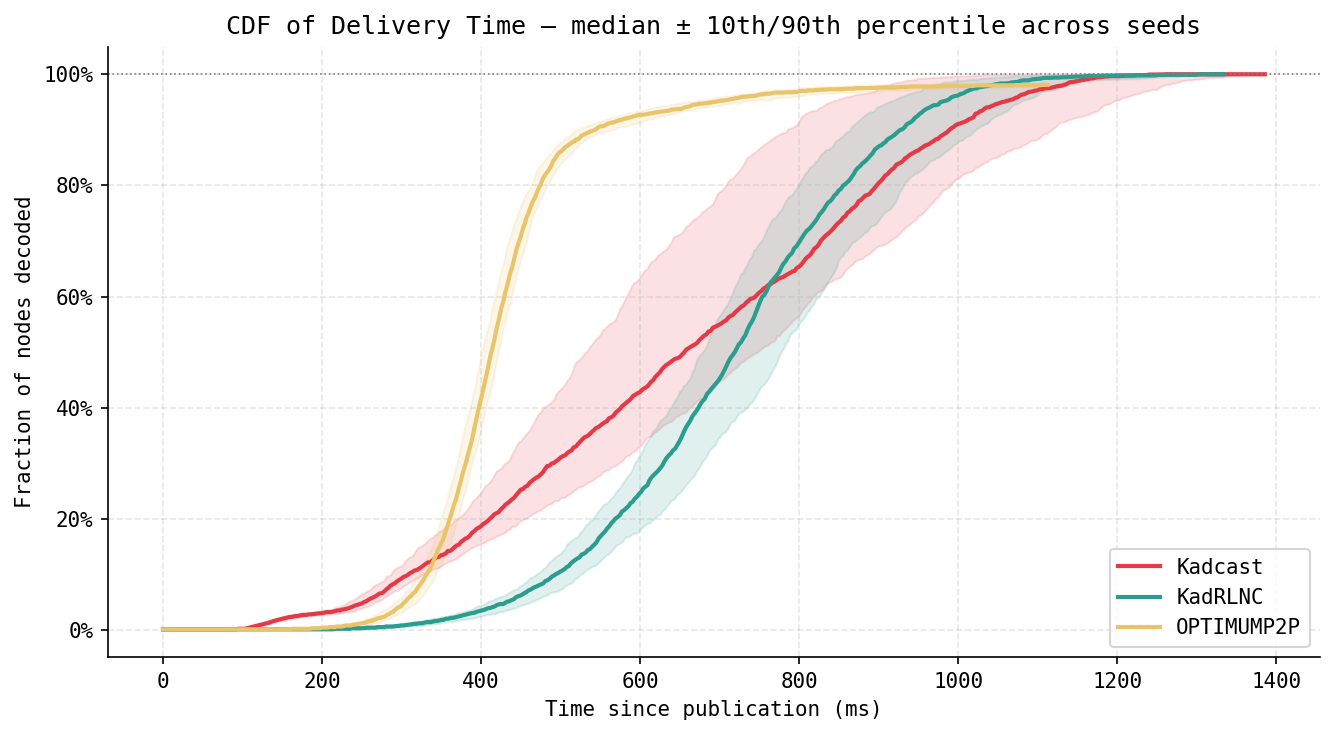

In [5]:
# =============================================================================
# 2. CDF of delivery time — one curve per protocol, shaded band = seed variance
# =============================================================================

def compute_cdf_per_run(df, n_points=500):
    """
    For each (seed, block_id), compute CDF of rel_time.
    Returns array of shape (n_runs, n_points) for time and fraction axes.
    """
    t_max  = df['rel_time'].quantile(0.999)
    t_grid = np.linspace(0, t_max, n_points)
    cdfs   = []
    for (seed, block), group in df.groupby(['seed', 'block_id']):
        times = np.sort(group['rel_time'].values)
        frac  = np.searchsorted(times, t_grid, side='right') / N_NODES
        cdfs.append(frac)
    return t_grid, np.array(cdfs)


fig, ax = plt.subplots(figsize=(9, 5))

for p in PROTOCOLS:
    t_grid, cdfs = compute_cdf_per_run(deliveries[p])
    median = np.median(cdfs, axis=0)
    lo     = np.percentile(cdfs, 10, axis=0)
    hi     = np.percentile(cdfs, 90, axis=0)
    c      = COLORS[p]
    ax.plot(t_grid, median, color=c, lw=2, label=LABELS[p])
    ax.fill_between(t_grid, lo, hi, color=c, alpha=0.15)

ax.axhline(1.0, color='grey', lw=0.8, ls=':')
ax.set_xlabel('Time since publication (ms)')
ax.set_ylabel('Fraction of nodes decoded')
ax.set_title('CDF of Delivery Time — median ± 10th/90th percentile across seeds')
ax.legend()
ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig('../figures/base/cdf_delivery.png', bbox_inches='tight')
plt.show()

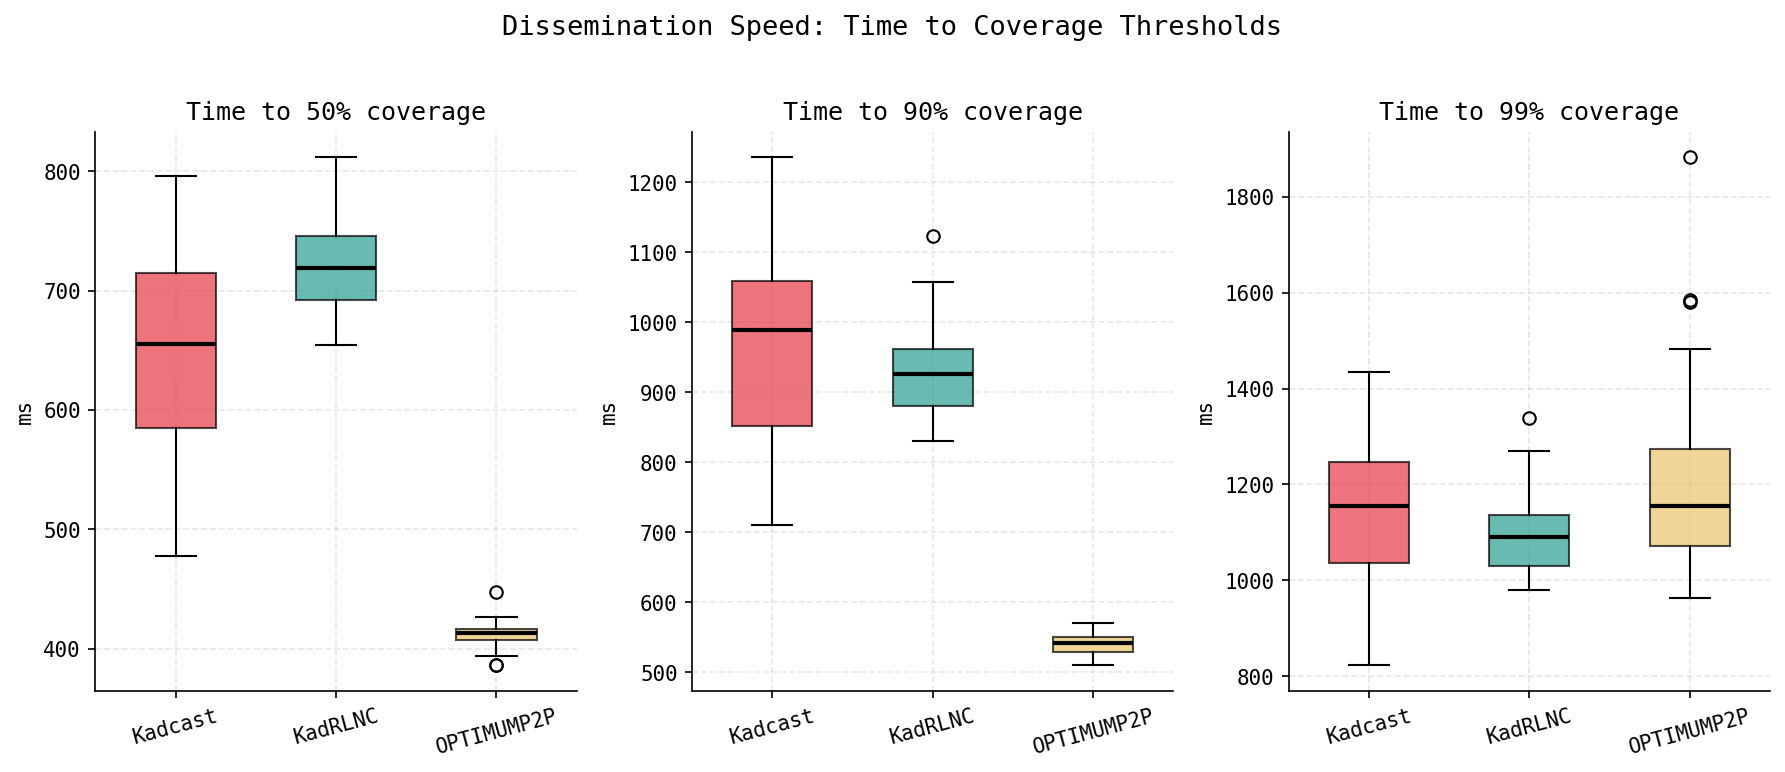

In [6]:
# =============================================================================
# 3. Time to X% coverage — box plots across seeds
# =============================================================================

THRESHOLDS = [0.50, 0.90, 0.99]

def time_to_coverage(df, thresholds, n_nodes):
    """
    For each (seed, block_id), find the time at which each threshold
    fraction of nodes has decoded.
    Returns dict: threshold -> list of times across all runs.
    """
    result = defaultdict(list)
    for (seed, block), group in df.groupby(['seed', 'block_id']):
        times = np.sort(group['rel_time'].values)
        for thr in thresholds:
            idx = int(np.ceil(thr * n_nodes)) - 1
            idx = min(idx, len(times) - 1)
            result[thr].append(times[idx])
    return result


fig, axes = plt.subplots(1, len(THRESHOLDS), figsize=(12, 5), sharey=False)

for i, thr in enumerate(THRESHOLDS):
    ax   = axes[i]
    data = [time_to_coverage(deliveries[p], [thr], N_NODES)[thr] for p in PROTOCOLS]
    bp   = ax.boxplot(data, patch_artist=True, widths=0.5,
                      medianprops=dict(color='black', lw=2))
    for patch, p in zip(bp['boxes'], PROTOCOLS):
        patch.set_facecolor(COLORS[p])
        patch.set_alpha(0.7)
    ax.set_xticks(range(1, len(PROTOCOLS)+1))
    ax.set_xticklabels([LABELS[p] for p in PROTOCOLS], rotation=15)
    ax.set_title(f'Time to {int(thr*100)}% coverage')
    ax.set_ylabel('ms')

plt.suptitle('Dissemination Speed: Time to Coverage Thresholds', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../figures/base/coverage_boxplots.png', bbox_inches='tight')
plt.show()

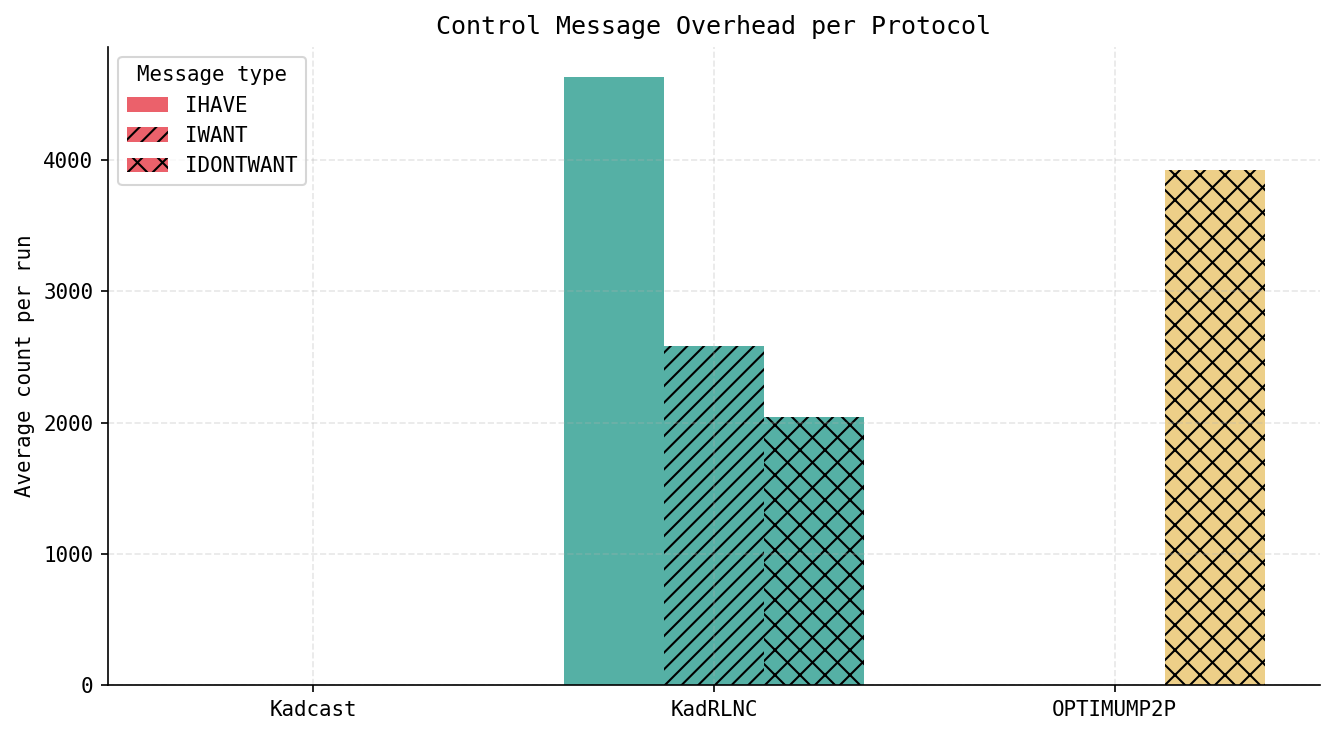

In [7]:
# =============================================================================
# 4. Control message counts per protocol
# =============================================================================

fig, ax = plt.subplots(figsize=(9, 5))

msg_types_all = ['IHAVE', 'IWANT', 'IDONTWANT']
x      = np.arange(len(PROTOCOLS))
width  = 0.25
hatch  = ['', '///', 'xx']

for i, mtype in enumerate(msg_types_all):
    counts = []
    for p in PROTOCOLS:
        df = messages[p]
        if df.empty or 'msg_type' not in df.columns:
            counts.append(0)
            continue
        # Average per (seed, block) run
        per_run = df[df['msg_type'] == mtype].groupby(['seed', 'block_id']).size()
        counts.append(per_run.mean() if not per_run.empty else 0)
    ax.bar(x + i*width, counts, width, label=mtype,
           color=[COLORS[p] for p in PROTOCOLS], alpha=0.8, hatch=hatch[i])

ax.set_xticks(x + width)
ax.set_xticklabels([LABELS[p] for p in PROTOCOLS])
ax.set_ylabel('Average count per run')
ax.set_title('Control Message Overhead per Protocol')
ax.legend(title='Message type')
plt.tight_layout()
plt.savefig('../figures/base/control_messages.png', bbox_inches='tight')
plt.show()

KadRLNC IHAVE→IWANT conversion rate (fraction of IHAVEs that got IWANT back):
  mean : 0.560
  std  : 0.024
  min  : 0.510
  max  : 0.615


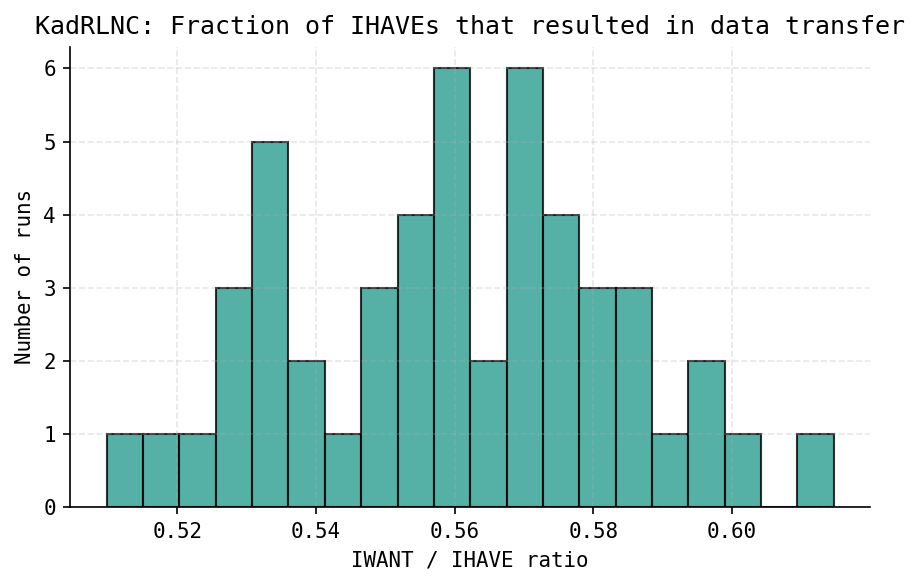

In [8]:
# =============================================================================
# 5. KadRLNC IHAVE efficiency — IWANT/IHAVE ratio
# =============================================================================

df_rl = messages['kadrlnc']
if not df_rl.empty:
    per_run = df_rl.groupby(['seed', 'block_id', 'msg_type']).size().unstack(fill_value=0)
    if 'IHAVE' in per_run.columns and 'IWANT' in per_run.columns:
        per_run['efficiency'] = per_run['IWANT'] / per_run['IHAVE']
        print("KadRLNC IHAVE→IWANT conversion rate (fraction of IHAVEs that got IWANT back):")
        print(f"  mean : {per_run['efficiency'].mean():.3f}")
        print(f"  std  : {per_run['efficiency'].std():.3f}")
        print(f"  min  : {per_run['efficiency'].min():.3f}")
        print(f"  max  : {per_run['efficiency'].max():.3f}")

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.hist(per_run['efficiency'], bins=20, color=COLORS['kadrlnc'], alpha=0.8, edgecolor='black')
        ax.set_xlabel('IWANT / IHAVE ratio')
        ax.set_ylabel('Number of runs')
        ax.set_title('KadRLNC: Fraction of IHAVEs that resulted in data transfer')
        plt.tight_layout()
        plt.savefig('../figures/base/kadrlnc_efficiency.png', bbox_inches='tight')
        plt.show()

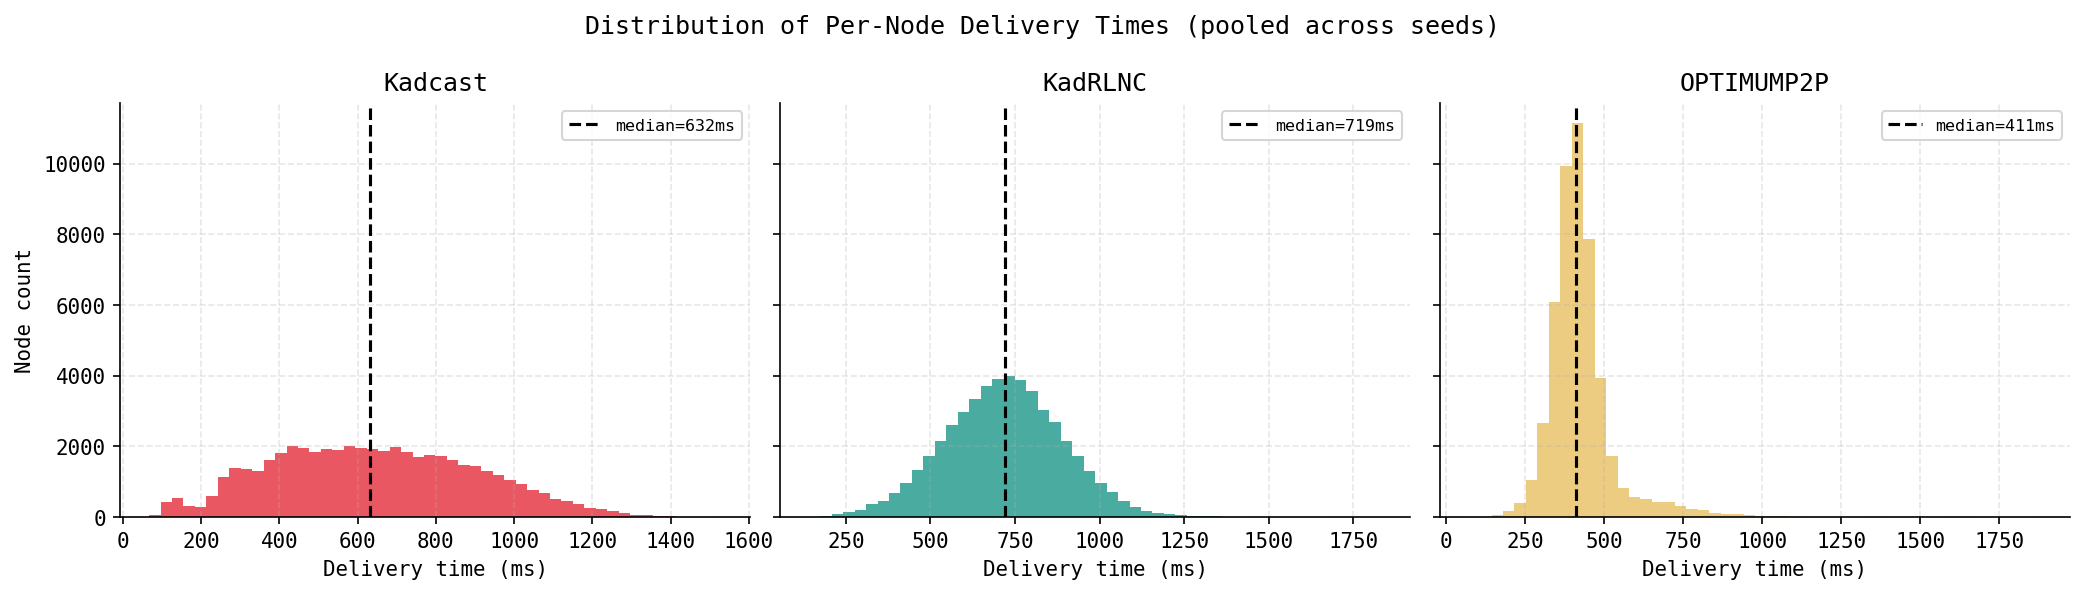

In [9]:
# =============================================================================
# 6. Delivery time histogram — distribution shape per protocol
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, p in zip(axes, PROTOCOLS):
    # Pool all rel_times across seeds and blocks
    times = deliveries[p]['rel_time'].values
    # Exclude source node (rel_time=0) from histogram for clarity
    times = times[times > 0]
    ax.hist(times, bins=50, color=COLORS[p], alpha=0.85, edgecolor='none')
    ax.set_title(LABELS[p])
    ax.set_xlabel('Delivery time (ms)')
    ax.axvline(np.median(times), color='black', lw=1.5, ls='--', label=f'median={np.median(times):.0f}ms')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Node count')
plt.suptitle('Distribution of Per-Node Delivery Times (pooled across seeds)', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/base/delivery_histograms.png', bbox_inches='tight')
plt.show()

In [10]:
# =============================================================================
# 7. Summary statistics table
# =============================================================================

rows = []
for p in PROTOCOLS:
    df     = deliveries[p]
    times  = df[df['rel_time'] > 0]['rel_time']
    cov    = time_to_coverage(df, [0.50, 0.90, 0.99], N_NODES)
    n_msgs = messages[p].shape[0] if not messages[p].empty else 0
    n_runs = df.groupby(['seed','block_id']).ngroups
    rows.append({
        'Protocol'        : LABELS[p],
        'Median delivery' : f"{times.median():.1f} ms",
        '99th pct'        : f"{times.quantile(0.99):.1f} ms",
        'T@50%'           : f"{np.median(cov[0.50]):.1f} ms",
        'T@90%'           : f"{np.median(cov[0.90]):.1f} ms",
        'T@99%'           : f"{np.median(cov[0.99]):.1f} ms",
        'Control msgs/run': f"{n_msgs/n_runs:.0f}",
    })

summary = pd.DataFrame(rows).set_index('Protocol')
summary

,Median delivery,99th pct,T@50%,T@90%,T@99%,Control msgs/run
Protocol,,,,,,
Kadcast,631.8 ms,1236.7 ms,655.3 ms,989.2 ms,1155.6 ms,0
KadRLNC,718.8 ms,1135.6 ms,719.0 ms,926.9 ms,1089.6 ms,9260
OPTIMUMP2P,410.8 ms,832.4 ms,412.8 ms,542.4 ms,1154.2 ms,3920


In [11]:
# Load shards CSV and compute overhead ratio

K = 32
SHARD_SIZE = 1024 * 1024 // K

for p in PROTOCOLS:
    shard_files = sorted(glob.glob(os.path.join(RESULTS_DIR, f'{p}_*_shards.csv')))
    frames = []
    for path in shard_files:
        seed = int(os.path.basename(path).split('_')[1])
        df = pd.read_csv(path)
        df['seed'] = seed
        frames.append(df)
    shards_df = pd.concat(frames)
    
    # Min bytes needed = k * shard_size * N_NODES
    min_bytes = K * SHARD_SIZE * N_NODES
    shards_df['overhead'] = (shards_df['shard_count'] * SHARD_SIZE) / min_bytes
    mean_oh = shards_df['overhead'].mean()
    print(f"{LABELS[p]}: mean overhead ratio = {mean_oh:.3f}x")

Kadcast: mean overhead ratio = 4.704x
KadRLNC: mean overhead ratio = 2.585x
OPTIMUMP2P: mean overhead ratio = 3.922x
